**Importing necessary libraries for data handling, feature extraction, model training, and evaluation.**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

** Loading the email dataset and displaying its contents.**

In [ ]:
df = pd.read_csv('mail_data.csv', encoding='latin-1')

In [ ]:
print(df)

     Category                                            Message
0         ham  Go until jurong point, crazy.. Available only ...
1         ham                      Ok lar... Joking wif u oni...
2        spam  Free entry in 2 a wkly comp to win FA Cup fina...
3         ham  U dun say so early hor... U c already then say...
4         ham  Nah I don't think he goes to usf, he lives aro...
...       ...                                                ...
5567     spam  This is the 2nd time we have tried 2 contact u...
5568      ham               Will ü b going to esplanade fr home?
5569      ham  Pity, * was in mood for that. So...any other s...
5570      ham  The guy did some bitching but I acted like i'd...
5571      ham                         Rofl. Its true to its name

[5572 rows x 2 columns]


In [ ]:
data = df.where((pd.notnull(df)),'')

** Handling any missing/null values by replacing them with empty strings.**

In [ ]:
data = df.fillna('')

In [ ]:
data.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
data.shape

(5572, 2)

**Converting text labels: 'spam' becomes 0, and 'ham' becomes 1 for model compatibility.**

In [ ]:
data.loc[data['Category']== 'spam','Category',] = 0
data.loc[data['Category']== 'ham','Category',] = 1

In [ ]:
X = data['Message']

Y = data['Category']

**Displaying the email messages and their corresponding labels.**

In [ ]:
print(X)

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                 Will ü b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: Message, Length: 5572, dtype: object


In [ ]:
print(Y)

0       1
1       1
2       0
3       1
4       1
       ..
5567    0
5568    1
5569    1
5570    1
5571    1
Name: Category, Length: 5572, dtype: object


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=3)

In [ ]:
print(X.shape)
print(X_train.shape)
print(X_test.shape)

(5572,)
(4457,)
(1115,)


In [ ]:
print(Y.shape)
print(Y_train.shape)
print(Y_test.shape)

(5572,)
(4457,)
(1115,)


**Converting email text into numerical values using TF-IDF vectorization.**

In [ ]:
feature_extraction = TfidfVectorizer(min_df = 1, stop_words='english', lowercase=True)

X_train_features = feature_extraction.fit_transform(X_train)
X_test_features = feature_extraction.transform(X_test)

Y_train = Y_train.astype('int')
Y_test = Y_test.astype('int')

**Printing raw training data and its transformed (vectorized) format.**

In [ ]:
print(X_train)

3075                  Don know. I did't msg him recently.
1787    Do you know why god created gap between your f...
1614                         Thnx dude. u guys out 2nite?
4304                                      Yup i'm free...
3266    44 7732584351, Do you want a New Nokia 3510i c...
                              ...                        
789     5 Free Top Polyphonic Tones call 087018728737,...
968     What do u want when i come back?.a beautiful n...
1667    Guess who spent all last night phasing in and ...
3321    Eh sorry leh... I din c ur msg. Not sad alread...
1688    Free Top ringtone -sub to weekly ringtone-get ...
Name: Message, Length: 4457, dtype: object


In [ ]:
print(X_train_features)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 34775 stored elements and shape (4457, 7431)>
  Coords	Values
  (0, 2329)	0.38783870336935383
  (0, 3811)	0.34780165336891333
  (0, 2224)	0.413103377943378
  (0, 4456)	0.4168658090846482
  (0, 5413)	0.6198254967574347
  (1, 3811)	0.17419952275504033
  (1, 3046)	0.2503712792613518
  (1, 1991)	0.33036995955537024
  (1, 2956)	0.33036995955537024
  (1, 2758)	0.3226407885943799
  (1, 1839)	0.2784903590561455
  (1, 918)	0.22871581159877646
  (1, 2746)	0.3398297002864083
  (1, 2957)	0.3398297002864083
  (1, 3325)	0.31610586766078863
  (1, 3185)	0.29694482957694585
  (1, 4080)	0.18880584110891163
  (2, 6601)	0.6056811524587518
  (2, 2404)	0.45287711070606745
  (2, 3156)	0.4107239318312698
  (2, 407)	0.509272536051008
  (3, 7415)	0.8100020912469564
  (3, 2870)	0.5864269879324768
  (4, 2870)	0.41872147309323743
  (4, 487)	0.2899118421746198
  :	:
  (4454, 2855)	0.47210665083641806
  (4454, 2246)	0.47210665083641806
  (4455, 4456)	0.24

** Creating and training the Logistic Regression model on the training data.**


In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(X_train_features, Y_train)

LogisticRegression()

**Checking how well the model performs on the training data.**

In [ ]:
prediction_on_training_data = model.predict(X_train_features)
accuracy_on_training_data = accuracy_score(Y_train, prediction_on_training_data)

In [ ]:
print('Acc on training data : ', accuracy_on_training_data)

Acc on training data :  0.9676912721561588


**Evaluating the model’s accuracy on unseen test data.**

In [ ]:
prediction_on_test_data = model.predict(X_test_features)
accuracy_on_test_data = accuracy_score(Y_test, prediction_on_test_data)

In [ ]:
print('Acc on test data : ', accuracy_on_test_data)

Acc on test data :  0.9668161434977578


**Testing the model on a new, custom email & Printing the result based on prediction: 1 for ham, 0 for spam.**



In [ ]:
mail = ["This is the 2nd time we have tried to conatct u. U have won $200 prize"]
input_data_features = feature_extraction.transform(mail)

prediction = model.predict(input_data_features)
print(prediction)

if (prediction[0] == 1):
  print('Ham mail')
else:
  print('Spam mail')

[0]
Spam mail


In [ ]:
mail = ["Win a brand new iPhone 14 for just $1. Limited time offer, sign up now!"]
input_data_features = feature_extraction.transform(mail)

prediction = model.predict(input_data_features)
print(prediction)

if (prediction[0] == 1):
  print('Ham mail')
else:
  print('Spam mail')

[1]
Ham mail


In [ ]:
mail =["Our team has a special offer available this month. Let us know if you’re interested."]
input_data_features = feature_extraction.transform(mail)

prediction = model.predict(input_data_features)
print(prediction)

if (prediction[0] == 1):
  print('Ham mail')
else:
  print('Spam mail')

[1]
Ham mail


E-MAIL EXAMPLES :

email_1 = "Congratulations! You've won a $1,000 Walmart gift card. Click here to claim now."

email_2 = "URGENT: Your account has been compromised. Verify your identity immediately."

email_3 = "Win a brand new iPhone 14 for just $1. Limited time offer, sign up now!"

email_4 = "Earn $500 a day from home! No experience needed. Start today!"

email_5 = "This is the FINAL notice about your loan pre-approval. Act now!"

 Visualizes the confusion matrix using a heatmap, making it easier to interpret correct vs incorrect predictions.

Accuracy: 0.9668161434977578

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.76      0.86       155
           1       0.96      1.00      0.98       960

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115


Confusion Matrix:
 [[118  37]
 [  0 960]]


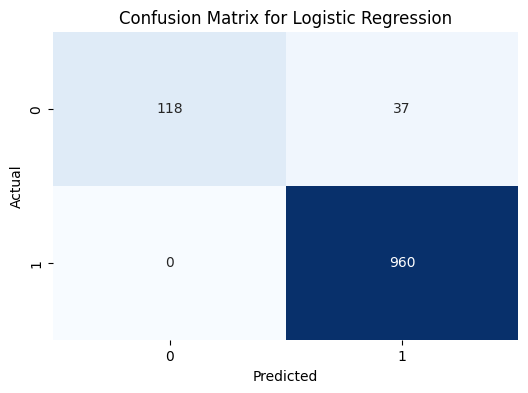

In [ ]:
# Evaluate the model
accuracy = accuracy_score(Y_test, prediction_on_test_data)
report = classification_report(Y_test, prediction_on_test_data)
conf_matrix = confusion_matrix(Y_test, prediction_on_test_data)

print("Accuracy:", accuracy)
print("\nClassification Report:\n", report)
print("\nConfusion Matrix:\n", conf_matrix)

# Confusion Matrix for Logistic Regression
cm = confusion_matrix(Y_test, prediction_on_test_data)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

**We evaluated the model using accuracy and classification metrics. We also plotted the confusion matrix to visualize how many spam and ham emails were correctly or incorrectly predicted.**

**Create a dictionary of 4 classification models to test and compare: Logistic Regression, Naive Bayes, Support Vector Machine (SVM), and Random Forest.**

In [ ]:
data.loc[data['Category']== 'spam','Category',] = 0
data.loc[data['Category']== 'ham','Category',] = 1

X = data['Message']
Y = data['Category']

# Split data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=3)

Y_train = pd.to_numeric(Y_train, errors='coerce').astype(int)
Y_test = pd.to_numeric(Y_test, errors='coerce').astype(int)

In [ ]:
test_emails = [
    "Win a free iPhone 15 now! Click here to claim your prize.",
    "Hi Alex, just checking if we’re still on for the meeting tomorrow.",
    "Final notice: your account will be closed unless you respond immediately!",
]

print("\n--- Predictions on Sample Emails ---")
for name, model in models.items():
    # Use feature_extraction instead of vectorizer to transform test_emails
    test_features = feature_extraction.transform(test_emails)
    # Fit the model before making predictions
    model.fit(X_train_features, Y_train)  # Add this line to train the model
    preds = model.predict(test_features)
    print(f"\n{name} Predictions:")
    for i, pred in enumerate(preds):
        label = "Ham" if pred == 1 else "Spam"
        print(f"Email {i+1}: {label} — {test_emails[i]}")


--- Predictions on Sample Emails ---

Logistic Regression Predictions:
Email 1: Spam — Win a free iPhone 15 now! Click here to claim your prize.
Email 2: Ham — Hi Alex, just checking if we’re still on for the meeting tomorrow.
Email 3: Ham — Final notice: your account will be closed unless you respond immediately!

Naive Bayes Predictions:
Email 1: Spam — Win a free iPhone 15 now! Click here to claim your prize.
Email 2: Ham — Hi Alex, just checking if we’re still on for the meeting tomorrow.
Email 3: Ham — Final notice: your account will be closed unless you respond immediately!

SVM Predictions:
Email 1: Spam — Win a free iPhone 15 now! Click here to claim your prize.
Email 2: Ham — Hi Alex, just checking if we’re still on for the meeting tomorrow.
Email 3: Spam — Final notice: your account will be closed unless you respond immediately!

Random Forest Predictions:
Email 1: Spam — Win a free iPhone 15 now! Click here to claim your prize.
Email 2: Ham — Hi Alex, just checking if we’re

**CONCLUSION : Logistic Regression or SVM are the best models for email spam detection —
they both handle high-dimensional text features well and give high accuracy with low false positives.**